# Imports

In [1]:
!pip install rasterio
!pip install ptflops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 80.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import gc
import cv2
import os
from pathlib import Path
import rasterio
import matplotlib.pyplot as plt
from ptflops import get_model_complexity_info

from sklearn.model_selection import train_test_split


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim
from torchvision import transforms
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.profiler import profile, record_function, ProfilerActivity

# Constants

In [3]:
DATASET_DIR = Path("/kaggle/input/cloud-masking-dataset/content/train")
IMG_DIR =   DATASET_DIR / "data"
MASK_DIR =   DATASET_DIR / "masks"
MODEL_PATH = "/kaggle/working/best_cloud_net.pth"

In [4]:
bad_imgs = ["406461.tif", "874668.tif","953740.tif","185569.tif","523808.tif","541314.tif","977340.tif","140163.tif","343962.tif","757386.tif","998435.tif","805477.tif","750810.tif","766738.tif",
"319869.tif","726495.tif","195656.tif","961186.tif","664107.tif","694587.tif","577538.tif","934794.tif","891662.tif","534303.tif","262602.tif","933456.tif","811451.tif","531589.tif","574760.tif",
"872882.tif","539486.tif","688215.tif","715870.tif","385166.tif","602248.tif","796353.tif","439498.tif","585242.tif","726667.tif","962529.tif","704238.tif","333752.tif","136346.tif","140804.tif",
"850435.tif","262934.tif","600318.tif","749468.tif","452058.tif","220031.tif","606957.tif","294760.tif","220936.tif","721826.tif","434132.tif","611945.tif","385959.tif","356639.tif","280222.tif",
"229204.tif","165308.tif","264631.tif","220020.tif","504630.tif","233470.tif","340927.tif","622669.tif","616780.tif","628027.tif","774225.tif","207241.tif","113390.tif","699573.tif","888669.tif",
"946561.tif","873048.tif","718115.tif","505910.tif","999876.tif","196126.tif","986486.tif","469954.tif","390120.tif","831514.tif","355671.tif","276214.tif","951211.tif","311740.tif","223481.tif",
"767578.tif","588533.tif","476018.tif","892313.tif","567574.tif","757629.tif","742818.tif","502460.tif","979988.tif","936223.tif","730421.tif","892170.tif","531641.tif","452457.tif","382154.tif",
"690180.tif","550513.tif","191884.tif","413118.tif","684482.tif","171789.tif","546157.tif","533377.tif","400692.tif","501312.tif","738635.tif","327408.tif","843793.tif","700534.tif","204721.tif",
"517885.tif","947438.tif","950155.tif","299836.tif","131064.tif","120337.tif","673167.tif","673167.tif","710434.tif","289430.tif","769983.tif","233533.tif","325595.tif","43423.tif","541315.tif",
"213000.tif","573039.tif","475565.tif","310647.tif","251631.tif","235047.tif","288128.tif","976303.tif","261771.tif","988811.tif","956360.tif","888939.tif","799565.tif","558737.tif","556379.tif",
"236435.tif","398910.tif","637566.tif",
"104539.tif","508060.tif","134677.tif","512042.tif","435788.tif","876909.tif","230734.tif","216587.tif","926097.tif","718697.tif","230734.tif","352249.tif","282237.tif",# "852146.tif",# "970969.tif",
"398916.tif","384076.tif","812597.tif","678469.tif","378727.tif","178465.tif","883171.tif","518309.tif","953266.tif","954814.tif","908812.tif","889743.tif","359249.tif","303765.tif","229660.tif",
"916344.tif","282085.tif","618746.tif","946335.tif","616428.tif","935434.tif","548906.tif","714054.tif","703178.tif","886197.tif","148001.tif","539976.tif","676884.tif","123107.tif","465509.tif",
"912085.tif","675512.tif","426084.tif","110215.tif","486244.tif","604605.tif","979249.tif","755602.tif","153097.tif","920934.tif","742108.tif","570405.tif","326441.tif","741055.tif","241276.tif",
"487896.tif","932250.tif","226516.tif","601903.tif","498591.tif","265759.tif","538446.tif","913594.tif","325583.tif","849937.tif","308496.tif","709908.tif","158936.tif","202827.tif","179710.tif",
"379766.tif","353480.tif","626491.tif","338968.tif","651002.tif","568288.tif","317273.tif","324729.tif","734155.tif","145548.tif","934908.tif","645895.tif","216968.tif","998746.tif","895248.tif",
"659713.tif","409478.tif","221620.tif","226611.tif",
"356622.tif","931420.tif","570711.tif",
"829987.tif","819916.tif",
"835325.tif","824586.tif","912767.tif",
"384815.tif","402380.tif","275526.tif","420349.tif","179013.tif","649855.tif","211090.tif","873774.tif","584045.tif","126135.tif","446265.tif","660324.tif","379133.tif","806215.tif","410401.tif","526117.tif","918213.tif","211425.tif","555052.tif","507524.tif","855777.tif","826501.tif","299800.tif","370413.tif","321659.tif","787657.tif","785611.tif","883159.tif","483349.tif","643899.tif","643899.tif","752878.tif","663356.tif","524252.tif","685466.tif","561865.tif","756401.tif","524707.tif","639764.tif","407419.tif","781463.tif","971230.tif","907236.tif","693616.tif","148205.tif","193670.tif","147623.tif","470774.tif","398911.tif","909000.tif","638289.tif","361728.tif","557592.tif","576849.tif","419491.tif","404704.tif","609462.tif","176604.tif","142859.tif","588316.tif","443492.tif","907812.tif","628313.tif","171951.tif","616342.tif","988217.tif","180657.tif","652266.tif","958620.tif","789023.tif","647639.tif","929912.tif","750810.tif","953452.tif","931016.tif","354085.tif","228479.tif","768480.tif","194952.tif","406327.tif","417003.tif","378517.tif","674553.tif","916356.tif","194782.tif","542828.tif","620306.tif","997287.tif","344303.tif","820539.tif","271241.tif","553633.tif","972064.tif","561023.tif","157217.tif","290724.tif","598940.tif","178629.tif","600811.tif","437742.tif","192742.tif","742917.tif","144894.tif","178957.tif","975804.tif","963508.tif","778748.tif","968581.tif","937302.tif","224582.tif","970196.tif","221628.tif","881206.tif","350786.tif","580728.tif","237606.tif","608257.tif","589710.tif","253235.tif","842866.tif","570622.tif","373943.tif","882033.tif","500112.tif","943726.tif","949884.tif","744693.tif","327900.tif","409222.tif","825835.tif","881828.tif","817956.tif","777737.tif","974190.tif","699929.tif","290802.tif","712553.tif","975290.tif","316642.tif","980152.tif","983687.tif","527066.tif","637234.tif","968726.tif","749887.tif",
"397979.tif",
"280117.tif",
"991597.tif",
"820141.tif",
"788201.tif",
"588557.tif",
"773918.tif",
"165142.tif",
"103468.tif",
"132938.tif",
"333049.tif",
"714867.tif",
"760458.tif",
"246413.tif",
"723155.tif",
"158845.tif",
"276831.tif",
"700705.tif",
"819112.tif",
"415344.tif",
"421384.tif",
"570325.tif",
"268637.tif",
"538997.tif",
"487728.tif",
"319832.tif",
"938016.tif",
"300281.tif",
"261395.tif",
"534649.tif",
"116703.tif",
"310477.tif","563246.tif","954779.tif","182034.tif","716338.tif","946721.tif","247475.tif","484264.tif","767033.tif","269654.tif","539375.tif","278243.tif","848023.tif","535352.tif","566297.tif","139704.tif","310743.tif","499371.tif","737894.tif","549737.tif","401022.tif","370804.tif","547820.tif","905459.tif","189903.tif","662728.tif","221414.tif","366817.tif","677086.tif","538184.tif","240386.tif","193471.tif","199099.tif","774734.tif","966985.tif","353961.tif","137778.tif","255245.tif","636521.tif","272892.tif","972442.tif","468623.tif","598844.tif","497687.tif","656379.tif","820420.tif","233051.tif","964371.tif","168458.tif","395442.tif","786837.tif","891638.tif","594078.tif","790266.tif","920114.tif","829168.tif","834861.tif",
"729057.tif","910326.tif","453487.tif","252203.tif","885342.tif","294776.tif","896907.tif","980303.tif","122056.tif","172187.tif","287588.tif","940952.tif","309505.tif","982023.tif","768636.tif","774079.tif","656837.tif","286340.tif","668532.tif","227257.tif","290305.tif","560295.tif","507777.tif","606676.tif","759104.tif","561101.tif","154644.tif","609232.tif","993085.tif","779378.tif","401663.tif","102565.tif","482199.tif","552760.tif","231165.tif","451317.tif","356736.tif","989136.tif","615500.tif","999138.tif","884229.tif","207175.tif","706005.tif","178463.tif","271790.tif","701987.tif","793300.tif","987624.tif","505674.tif","775960.tif","324479.tif","240814.tif","434827.tif","346174.tif","791838.tif","416950.tif","335122.tif","861594.tif","437978.tif","874524.tif","415759.tif","167136.tif","693022.tif","269430.tif","677321.tif","403524.tif","672967.tif","735242.tif","378428.tif","679958.tif","231414.tif","243057.tif","458605.tif","687713.tif","766269.tif","803904.tif","377370.tif","850981.tif","189026.tif","240600.tif","451577.tif","902575.tif","427679.tif","614688.tif","175623.tif","405605.tif","742191.tif","445658.tif","953025.tif","962050.tif","765620.tif","349185.tif","650311.tif","155164.tif","838083.tif","442838.tif","510154.tif","748665.tif","313068.tif","987110.tif","586706.tif","172222.tif","904214.tif","312146.tif","262816.tif","349087.tif","279451.tif","664365.tif","250038.tif","144235.tif","321686.tif","433451.tif","988102.tif","152046.tif","675111.tif","143195.tif","903986.tif","809621.tif","594312.tif","226882.tif","436030.tif","333210.tif","800305.tif","143195.tif","815819.tif","392683.tif","884475.tif","594312.tif","226882.tif","436030.tif","903986.tif",
"714334.tif","831295.tif","168517.tif","936994.tif","972565.tif","378535.tif","553873.tif","700521.tif","747847.tif","739037.tif","911414.tif","771088.tif","260565.tif","866437.tif","708979.tif","910074.tif","434165.tif","154909.tif","221552.tif","190378.tif","813928.tif","354533.tif","341535.tif","685253.tif","879769.tif","629298.tif","933729.tif","496764.tif","289592.tif","225710.tif","239675.tif","819400.tif","910616.tif","656968.tif","609845.tif","420214.tif","875679.tif","794391.tif","503348.tif","443238.tif","127941.tif","596489.tif","167557.tif","978821.tif","455652.tif","587227.tif","575301.tif","497455.tif","555589.tif","389346.tif","269087.tif","950083.tif","231647.tif","479332.tif","269087.tif","436219.tif","869105.tif","762398.tif","820426.tif","142288.tif","413388.tif","301528.tif","927524.tif","427659.tif","563999.tif","502686.tif","777255.tif","194682.tif","586208.tif","398090.tif","753534.tif","827143.tif","507341.tif","114463.tif","608768.tif","860180.tif","665158.tif","719489.tif","976566.tif","835716.tif","474158.tif","191962.tif","591534.tif","998348.tif","611833.tif","796982.tif","440189.tif","483542.tif","402820.tif","191982.tif","152906.tif","789305.tif","309794.tif","840282.tif","617695.tif","224357.tif","863214.tif","803953.tif","289222.tif","278026.tif","789365.tif","302338.tif","182790.tif","676289.tif","938817.tif","782141.tif","575279.tif","419644.tif","755698.tif","749840.tif","912270.tif","760351.tif","239850.tif","801364.tif","733553.tif","465124.tif","809794.tif","664315.tif","465124.tif","597732.tif","838857.tif","713762.tif","571804.tif","901677.tif","711218.tif","983855.tif","184148.tif","851606.tif","991737.tif","130216.tif","329021.tif","256782.tif","568127.tif","215830.tif","135527.tif","869735.tif",
"503159.tif","624203.tif","350164.tif","631756.tif","908475.tif","112038.tif","856445.tif","891952.tif","662625.tif","598369.tif","743644.tif","763653.tif","398151.tif","936821.tif","273982.tif","247189.tif","161483.tif","377405.tif","281043.tif","829716.tif","907278.tif","432061.tif","389854.tif","269078.tif","975930.tif","859396.tif","563031.tif","583000.tif","835901.tif","428122.tif","274389.tif","865416.tif","660957.tif","725780.tif","549956.tif","980764.tif","952117.tif","928381.tif","295472.tif","454349.tif","986438.tif","377877.tif","748696.tif","797860.tif","690016.tif","299254.tif","563516.tif","297132.tif","923532.tif","633469.tif","106182.tif","181678.tif","510780.tif","330374.tif","156413.tif","873207.tif","378150.tif","824161.tif","926403.tif","230192.tif","214119.tif","655149.tif","707021.tif","910883.tif","111106.tif","843007.tif","952631.tif","683390.tif","696152.tif","180458.tif","476417.tif","642347.tif","403387.tif","827632.tif","556957.tif","140605.tif","152727.tif","611994.tif","986925.tif"
"993916.tif","950916.tif","956721.tif","783501.tif","586849.tif","611265.tif","390946.tif","197793.tif","196973.tif","155708.tif","608205.tif","476710.tif","949352.tif","218844.tif","447372.tif","352036.tif","788457.tif","105274.tif","532046.tif","153802.tif","775105.tif","281708.tif","189814.tif","489933.tif","999308.tif","422823.tif","192337.tif","818666.tif","101885.tif","202344.tif","486831.tif","211726.tif"]


In [5]:
len(bad_imgs)

862

In [6]:
img_names = [img_name.name for img_name in IMG_DIR.rglob("*") if img_name.name  not in bad_imgs]

In [7]:
len(img_names)

9724

In [8]:
del bad_imgs

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Modeling

In [10]:
class CloudNet(nn.Module):
    def __init__(self, input_rows=512, input_cols=512, num_of_channels=4, num_of_classes=1):
        super(CloudNet, self).__init__()
        self.conv1 = nn.Conv2d(num_of_channels, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv12 = nn.Conv2d(32, num_of_classes, kernel_size=1)

    def bn_relu(self, x):
        x = nn.BatchNorm2d(x.size(1))(x)
        x = F.relu(x)
        return x

    def contr_arm(self, x, filters, kernel_size):
        x1 = nn.Conv2d(x.size(1), filters, kernel_size=kernel_size, padding='same')(x)
        x1 = self.bn_relu(x1)
        x1 = nn.Conv2d(filters, filters, kernel_size=kernel_size, padding='same')(x1)
        x1 = self.bn_relu(x1)

        filters_b = filters // 2
        kernel_size_b = (kernel_size[0] - 2, kernel_size[0] - 2)
        x2 = nn.Conv2d(x.size(1), filters_b, kernel_size=kernel_size_b, padding='same')(x)
        x2 = self.bn_relu(x2)
        x2 = torch.cat([x, x2], dim=1)
        x = x1 + x2
        x = F.relu(x)
        return x

    def imprv_contr_arm(self, x, filters, kernel_size):
        x1 = nn.Conv2d(x.size(1), filters, kernel_size=kernel_size, padding='same')(x)
        x1 = self.bn_relu(x1)
        x0 = nn.Conv2d(filters, filters, kernel_size=kernel_size, padding='same')(x1)
        x0 = self.bn_relu(x0)
        x1 = nn.Conv2d(filters, filters, kernel_size=kernel_size, padding='same')(x0)
        x1 = self.bn_relu(x1)

        filters_b = filters // 2
        kernel_size_b = (kernel_size[0] - 2, kernel_size[0] - 2)
        x2 = nn.Conv2d(x.size(1), filters_b, kernel_size=kernel_size_b, padding='same')(x)
        x2 = self.bn_relu(x2)
        x2 = torch.cat([x, x2], dim=1)

        x3 = nn.Conv2d(filters, filters, kernel_size=kernel_size_b, padding='same')(x0)
        x3 = self.bn_relu(x3)

        x = x1 + x2 + x3
        x = F.relu(x)
        return x

    def bridge(self, x, filters, kernel_size):
        x1 = nn.Conv2d(x.size(1), filters, kernel_size=kernel_size, padding='same')(x)
        x1 = self.bn_relu(x1)
        x1 = nn.Conv2d(filters, filters, kernel_size=kernel_size, padding='same')(x1)
        x1 = nn.Dropout(0.15)(x1)
        x1 = self.bn_relu(x1)

        filters_b = filters // 2
        kernel_size_b = (kernel_size[0] - 2, kernel_size[0] - 2)
        x2 = nn.Conv2d(x.size(1), filters_b, kernel_size=kernel_size_b, padding='same')(x)
        x2 = self.bn_relu(x2)
        x2 = torch.cat([x, x2], dim=1)

        x = x1 + x2
        x = F.relu(x)
        return x

    def conv_block_exp_path(self, x, filters, kernel_size):
        x = nn.Conv2d(x.size(1), filters, kernel_size=kernel_size, padding='same')(x)
        x = self.bn_relu(x)
        x = nn.Conv2d(filters, filters, kernel_size=kernel_size, padding='same')(x)
        x = self.bn_relu(x)
        return x

    def conv_block_exp_path3(self, x, filters, kernel_size):
        x = nn.Conv2d(x.size(1), filters, kernel_size=kernel_size, padding='same')(x)
        x = self.bn_relu(x)
        x = nn.Conv2d(filters, filters, kernel_size=kernel_size, padding='same')(x)
        x = self.bn_relu(x)
        x = nn.Conv2d(filters, filters, kernel_size=kernel_size, padding='same')(x)
        x = self.bn_relu(x)
        return x

    def add_block_exp_path(self, x1, x2, x3):
        x = x1 + x2 + x3
        x = F.relu(x)
        return x

    def improve_ff_block4(self, x1, x2, x3, x4, pure_ff):
        for _ in range(1):
            x1 = torch.cat([x1, x1], dim=1)
        x1 = self.pool(x1)
        for _ in range(3):
            x2 = torch.cat([x2, x2], dim=1)
        x2 = nn.MaxPool2d(kernel_size=4, stride=4)(x2)
        for _ in range(7):
            x3 = torch.cat([x3, x3], dim=1)
        x3 = nn.MaxPool2d(kernel_size=8, stride=8)(x3)
        for _ in range(15):
            x4 = torch.cat([x4, x4], dim=1)
        x4 = nn.MaxPool2d(kernel_size=16, stride=16)(x4)
        x = x1 + x2 + x3 + x4 + pure_ff
        x = F.relu(x)
        return x

    def improve_ff_block3(self, x1, x2, x3, pure_ff):
        for _ in range(1):
            x1 = torch.cat([x1, x1], dim=1)
        x1 = self.pool(x1)
        for _ in range(3):
            x2 = torch.cat([x2, x2], dim=1)
        x2 = nn.MaxPool2d(kernel_size=4, stride=4)(x2)
        for _ in range(7):
            x3 = torch.cat([x3, x3], dim=1)
        x3 = nn.MaxPool2d(kernel_size=8, stride=8)(x3)
        x = x1 + x2 + x3 + pure_ff
        x = F.relu(x)
        return x

    def improve_ff_block2(self, x1, x2, pure_ff):
        for _ in range(1):
            x1 = torch.cat([x1, x1], dim=1)
        x1 = self.pool(x1)
        for _ in range(3):
            x2 = torch.cat([x2, x2], dim=1)
        x2 = nn.MaxPool2d(kernel_size=4, stride=4)(x2)
        x = x1 + x2 + pure_ff
        x = F.relu(x)
        return x

    def improve_ff_block1(self, x1, pure_ff):
        for _ in range(1):
            x1 = torch.cat([x1, x1], dim=1)
        x1 = self.pool(x1)
        x = x1 + pure_ff
        x = F.relu(x)
        return x

    def forward(self, x):
        conv1 = F.relu(self.conv1(x))
        conv1 = self.contr_arm(conv1, 32, (3, 3))
        pool1 = self.pool(conv1)
        conv2 = self.contr_arm(pool1, 64, (3, 3))
        pool2 = self.pool(conv2)
        conv3 = self.contr_arm(pool2, 128, (3, 3))
        pool3 = self.pool(conv3)
        conv4 = self.contr_arm(pool3, 256, (3, 3))
        pool4 = self.pool(conv4)
        conv5 = self.imprv_contr_arm(pool4, 512, (3, 3))
        pool5 = self.pool(conv5)
        conv6 = self.bridge(pool5, 1024, (3, 3))

        convT7 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2, padding=0)(conv6)
        prevup7 = self.improve_ff_block4(conv4, conv3, conv2, conv1, conv5)
        up7 = torch.cat([convT7, prevup7], dim=1)
        conv7 = self.conv_block_exp_path3(up7, 512, (3, 3))
        conv7 = self.add_block_exp_path(conv7, conv5, convT7)

        convT8 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2, padding=0)(conv7)
        prevup8 = self.improve_ff_block3(conv3, conv2, conv1, conv4)
        up8 = torch.cat([convT8, prevup8], dim=1)
        conv8 = self.conv_block_exp_path(up8, 256, (3, 3))
        conv8 = self.add_block_exp_path(conv8, conv4, convT8)

        convT9 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2, padding=0)(conv8)
        prevup9 = self.improve_ff_block2(conv2, conv1, conv3)
        up9 = torch.cat([convT9, prevup9], dim=1)
        conv9 = self.conv_block_exp_path(up9, 128, (3, 3))
        conv9 = self.add_block_exp_path(conv9, conv3, convT9)

        convT10 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2, padding=0)(conv9)
        prevup10 = self.improve_ff_block1(conv1, conv2)
        up10 = torch.cat([convT10, prevup10], dim=1)
        conv10 = self.conv_block_exp_path(up10, 64, (3, 3))
        conv10 = self.add_block_exp_path(conv10, conv2, convT10)

        convT11 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2, padding=0)(conv10)
        up11 = torch.cat([convT11, conv1], dim=1)
        conv11 = self.conv_block_exp_path(up11, 32, (3, 3))
        conv11 = self.add_block_exp_path (conv11, conv1, convT11)

        conv12 = self.conv12(conv11)
        return torch.sigmoid(conv12)

def model_arch(input_rows=512, input_cols=512, num_of_channels=4, num_of_classes=1):
    return CloudNet(input_rows, input_cols, num_of_channels, num_of_classes)

In [11]:
class CloudNet(nn.Module):
    def __init__(self, input_rows=512, input_cols=512, num_of_channels=4, num_of_classes=1):
        super(CloudNet, self).__init__()
        
        # Encoder
        self.conv1 = nn.Sequential(
            nn.Conv2d(num_of_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        
        # Decoder with Deep Supervision
        self.upconv4 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec4 = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        self.upconv3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.upconv2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        
        self.upconv1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        
        # Deep supervision outputs
        self.ds4 = nn.Conv2d(128, num_of_classes, kernel_size=1)
        self.ds3 = nn.Conv2d(64, num_of_classes, kernel_size=1)
        self.ds2 = nn.Conv2d(32, num_of_classes, kernel_size=1)
        
        # Final output
        self.final = nn.Conv2d(16, num_of_classes, kernel_size=1)
        
        # Upsampling layers for deep supervision
        self.ds4_upsample = nn.ConvTranspose2d(num_of_classes, num_of_classes, kernel_size=8, stride=8)
        self.ds3_upsample = nn.ConvTranspose2d(num_of_classes, num_of_classes, kernel_size=4, stride=4)
        self.ds2_upsample = nn.ConvTranspose2d(num_of_classes, num_of_classes, kernel_size=2, stride=2)

    def forward(self, x):
        # Encoder
        conv1 = self.conv1(x)        # [B, 16, 512, 512]
        pool1 = self.pool(conv1)     # [B, 16, 256, 256]
        
        conv2 = self.conv2(pool1)    # [B, 32, 256, 256]
        pool2 = self.pool(conv2)     # [B, 32, 128, 128]
        
        conv3 = self.conv3(pool2)    # [B, 64, 128, 128]
        pool3 = self.pool(conv3)     # [B, 64, 64, 64]
        
        conv4 = self.conv4(pool3)    # [B, 128, 64, 64]
        pool4 = self.pool(conv4)     # [B, 128, 32, 32]
        
        # Bottleneck
        bottleneck = self.bottleneck(pool4)  # [B, 256, 32, 32]
        
        # Decoder with Deep Supervision
        up4 = self.upconv4(bottleneck)      # [B, 128, 64, 64]
        up4 = torch.cat([up4, conv4], dim=1) # [B, 256, 64, 64]
        dec4 = self.dec4(up4)               # [B, 128, 64, 64]
        ds4_out = self.ds4_upsample(self.ds4(dec4))  # [B, 1, 512, 512]
        
        up3 = self.upconv3(dec4)            # [B, 64, 128, 128]
        up3 = torch.cat([up3, conv3], dim=1) # [B, 128, 128, 128]
        dec3 = self.dec3(up3)               # [B, 64, 128, 128]
        ds3_out = self.ds3_upsample(self.ds3(dec3))  # [B, 1, 512, 512]
        
        up2 = self.upconv2(dec3)            # [B, 32, 256, 256]
        up2 = torch.cat([up2, conv2], dim=1) # [B, 64, 256, 256]
        dec2 = self.dec2(up2)               # [B, 32, 256, 256]
        ds2_out = self.ds2_upsample(self.ds2(dec2))  # [B, 1, 512, 512]
        
        # Final output
        up1 = self.upconv1(dec2)            # [B, 16, 512, 512]
        up1 = torch.cat([up1, conv1], dim=1) # [B, 32, 512, 512]
        dec1 = self.dec1(up1)               # [B, 16, 512, 512]
        final_out = self.final(dec1)         # [B, 1, 512, 512]
        
        return {
            'final': torch.sigmoid(final_out),
            'ds2': torch.sigmoid(ds2_out),
            'ds3': torch.sigmoid(ds3_out),
            'ds4': torch.sigmoid(ds4_out)
        }

In [12]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return 1 - dice

In [13]:
class CustomDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_names, transform=None):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.img_names = img_names
        self.transform = transform
        
        self.means = np.array([2837.04085609, 2831.98116589, 2734.94209197, 3677.72763665], dtype=np.float16)
        self.stds = np.array([3190.10911234, 2927.71436665, 2814.50304193 ,2432.04465005], dtype=np.float16)  # Replace with real stds!
    
    def __len__(self):
        return len(self.img_names)
        
    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = self.img_dir / img_name
        mask_path = self.mask_dir / img_name
        
        try:
            with rasterio.open(img_path) as src:
                image = src.read()  # Shape: [4, H, W]
                image = image.astype(np.float32)  # Use float32 for stability
                
                # Normalize
                image = (image - self.means[:, None, None]) / self.stds[:, None, None]
                
                # Convert to tensor and ensure channel-first
                image = torch.from_numpy(image)  # [4, H, W]
    
            with rasterio.open(mask_path) as src:
                mask = (src.read(1) > 0).astype(np.float32)
                mask = torch.from_numpy(mask).unsqueeze(0)  # [1, H, W]
    
            return image, mask
    
        except Exception as e:
            print(f"Error loading {img_name}: {str(e)}")
            return torch.zeros((4, 512, 512)), torch.zeros((1, 512, 512))

    def get_name(self, idx):
        """Returns the filename for a given index"""
        return self.img_names[idx]

In [14]:
def compute_grad_cam(model, image, mask, layer_name, device, save_path):
    """Modified GRAD-CAM function for dictionary outputs"""
    # Store gradients and activations
    gradients = []
    activations = []
    
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())
        
    def forward_hook(module, input, output):
        activations.append(output.detach())
    
    # Register hooks
    target_layer = None
    for name, module in model.named_modules():
        if name == layer_name:
            target_layer = module
            break
    
    if target_layer is None:
        raise ValueError(f"Layer {layer_name} not found in model")
    
    backward_hook = target_layer.register_full_backward_hook(backward_hook)
    forward_hook = target_layer.register_forward_hook(forward_hook)
    
    try:
        # Forward pass - use final output only
        image = image.unsqueeze(0).to(device)
        image.requires_grad_(True)
        
        with torch.autocast(device_type='cuda', enabled=True):
            outputs = model(image)
            target = outputs['final'][0,0].sum()  # Access final output
            
        # Backward pass
        model.zero_grad()
        target.backward()
        
        # Compute CAM
        gradients = gradients[0].mean(dim=(2,3), keepdim=True)
        activations = activations[0]
        cam = (gradients * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=image.shape[2:], mode='bilinear', align_corners=False)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        # Visualization
        image_np = image[0].cpu().permute(1,2,0).detach().numpy()
        cam_np = cam[0,0].cpu().numpy()
        
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.imshow(image_np)
        plt.title("Original")
        plt.axis('off')
        
        plt.subplot(1,2,2)
        plt.imshow(image_np)
        plt.imshow(cam_np, cmap='jet', alpha=0.5)
        plt.title("GRAD-CAM")
        plt.axis('off')
        
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
        plt.close()
        
    finally:
        # Remove hooks
        backward_hook.remove()
        forward_hook.remove()

In [15]:
def get_model_ops(model, input_shape = (4, 512, 512)):
    macs, params = get_model_complexity_info(
        model,
        input_shape,
        as_strings=False,
        print_per_layer_stat=False,
        verbose=False
    )
    flops = macs * 2  # Convert MACs to FLOPs
    return flops, params

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, accum_steps=2):
    # Initialize components
    scaler = GradScaler()
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    
    # Setup directories and files
    gradcam_save_dir = "gradcam_outputs"
    os.makedirs(gradcam_save_dir, exist_ok=True)
    os.makedirs('/kaggle/working/log/profiler', exist_ok=True)
    log_file = "/kaggle/working/model_logs.txt"
    
    # Profiling setup
    profiler_schedule = torch.profiler.schedule(
        wait=1,
        warmup=1,
        active=3,
        repeat=2
    )

    for epoch in range(1, num_epochs+1):
        # Training phase
        model.train()
        train_loss = 0.0
        train_dice = 0.0
        optimizer.zero_grad()

        with torch.profiler.profile(
            activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
            schedule=profiler_schedule,
            record_shapes=True,
            profile_memory=True,
            with_stack=False
        ) as prof:
            for i, (images, masks) in enumerate(train_loader):
                images, masks = images.to(device), masks.to(device)
                
                with autocast():
                    # Forward pass - now returns dictionary of outputs
                    outputs = model(images)
                    
                    # Calculate multi-scale losses
                    loss_main = criterion(outputs['final'], masks)
                    loss_ds2 = criterion(outputs['ds2'], masks)
                    loss_ds3 = criterion(outputs['ds3'], masks)
                    loss_ds4 = criterion(outputs['ds4'], masks)
                    
                    # Weighted sum of losses
                    loss = (1.0 * loss_main + 
                           0.6 * loss_ds2 + 0.3 * loss_ds3 + 0.1 * loss_ds4)
                
                # Gradient accumulation
                scaler.scale(loss).backward()
                
                if (i + 1) % accum_steps == 0:
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()

                # Update metrics - using main output for dice calculation
                train_loss += loss.item() * accum_steps * images.size(0)
                
                # Compute Dice score on main output
                with torch.no_grad():
                    pred = (outputs['final'] > 0.5).float()
                    masks_flat = masks.view(masks.size(0), -1)
                    pred_flat = pred.view(pred.size(0), -1)
                    intersection = (pred_flat * masks_flat).sum(dim=1)
                    dice = (2. * intersection + 1e-7) / (pred_flat.sum(dim=1) + masks_flat.sum(dim=1) + 1e-7)
                    train_dice += dice.sum().item()

                prof.step()

        # Calculate epoch metrics
        train_loss /= len(train_loader.dataset)
        train_dice /= len(train_loader.dataset)

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        
        with torch.no_grad():
            for i, (images, masks) in enumerate(val_loader):
                images, masks = images.to(device), masks.to(device)
                
                # Only compute final output during validation for efficiency
                outputs = model(images)['final']
                val_loss += criterion(outputs, masks).item() * images.size(0)
                
                # Calculate dice on validation set
                pred = (outputs > 0.5).float()
                dice = (2 * (pred * masks).sum() + 1e-7) / (pred.sum() + masks.sum() + 1e-7)
                val_dice += dice.item() * images.size(0)
                
                # GRAD-CAM (only on final output)
                if (epoch == 1 or epoch == num_epochs) and i == 0:
                    for j in range(min(2, images.size(0))):
                        with autocast():
                            with torch.enable_grad():
                                img_name = val_loader.dataset.get_name(i*val_loader.batch_size + j)
                                save_path = os.path.join(gradcam_save_dir, 
                                                       f"gradcam_epoch{epoch}_{img_name}.png")
                                
                                compute_grad_cam(
                                    model=model,
                                    image=images[j],
                                    mask=masks[j],
                                    layer_name="dec1.3",  # Example layer
                                    device=device,
                                    save_path=save_path
                                )
                                torch.cuda.empty_cache()

        val_loss /= len(val_loader.dataset)
        val_dice /= len(val_loader.dataset)
        scheduler.step(val_dice)
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f"Epoch {epoch}/{num_epochs}, LR: {current_lr:.2e}")
        print(f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")
        
            
        torch.save(model.state_dict(), f'checkpoint_epoch_{epoch}.pth')
        torch.cuda.empty_cache()

    # Final operations
    flops, params = get_model_ops(model)
    
    with open(log_file, "w") as f:
        f.write(f"Number of Parameters: {params:,}\n")
        f.write(f"FLOPs: {flops:,}\n")
        
    prof.export_chrome_trace("trace.json")

In [17]:
# Clear GPU memory at start
gc.collect()
torch.cuda.empty_cache()
print(f"Initial GPU memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GiB allocated, "
      f"{torch.cuda.memory_reserved() / 1024**3:.2f} GiB reserved")

Initial GPU memory: 0.00 GiB allocated, 0.00 GiB reserved


In [18]:
val_split = 0.2

# Split into training and test sets
train_img_names, val_img_names = train_test_split(
    img_names, test_size=val_split, random_state=42
)
print(f"Training images: {len(train_img_names)}, Validation images: {len(val_img_names)}")

Training images: 7779, Validation images: 1945


In [19]:
batch_size = 8
learning_rate = 1e-3
num_epochs = 25
train_split = 0.8
accum_steps = 2 # Simulate batch size of 8 (4 * 2)

transform = transforms.Compose([
        transforms.ToTensor(),
    ])

# Datasets and DataLoaders
train_dataset = CustomDataset(IMG_DIR, MASK_DIR, train_img_names, transform)
val_dataset = CustomDataset(IMG_DIR, MASK_DIR, val_img_names, transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Model, loss, optimizer
model = model_arch(num_of_channels=4, num_of_classes=1).to(device)
criterion = DiceLoss() 
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, accum_steps)

/tmp/ipykernel_31/418698973.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_31/418698973.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_31/418698973.py:100: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/25, LR: 1.00e-03
Train Loss: 0.7468, Train Dice: 0.7858
Val Loss: 0.1022, Val Dice: 0.9060
Epoch 2/25, LR: 1.00e-03
Train Loss: 0.3749, Train Dice: 0.8254
Val Loss: 0.1047, Val Dice: 0.8973
Epoch 3/25, LR: 1.00e-03
Train Loss: 0.3454, Train Dice: 0.8314
Val Loss: 0.0658, Val Dice: 0.9351
Epoch 4/25, LR: 1.00e-03
Train Loss: 0.3117, Train Dice: 0.8477
Val Loss: 0.0667, Val Dice: 0.9336
Epoch 5/25, LR: 1.00e-03
Train Loss: 0.3123, Train Dice: 0.8514
Val Loss: 0.0757, Val Dice: 0.9246
Epoch 6/25, LR: 5.00e-04
Train Loss: 0.2876, Train Dice: 0.8571
Val Loss: 0.0657, Val Dice: 0.9344
Epoch 7/25, LR: 5.00e-04
Train Loss: 0.2668, Train Dice: 0.8671
Val Loss: 0.0607, Val Dice: 0.9394
Epoch 8/25, LR: 5.00e-04
Train Loss: 0.2590, Train Dice: 0.8712
Val Loss: 0.0622, Val Dice: 0.9379
Epoch 9/25, LR: 5.00e-04
Train Loss: 0.2561, Train Dice: 0.8753
Val Loss: 0.0542, Val Dice: 0.9458
Epoch 10/25, LR: 5.00e-04
Train Loss: 0.2561, Train Dice: 0.8725
Val Loss: 0.0585, Val Dice: 0.9416
Epoch 11/

In [20]:
def evaluate_thresholds(model, dataloader, device, n_thresholds=20):
    """Evaluate model performance across different decision thresholds"""
    model.eval()
    thresholds = np.linspace(0.1, 0.9, n_thresholds)
    results = {'threshold': [], 'dice': [], 'precision': [], 'recall': []}
    
    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)['final'].sigmoid().cpu().numpy()
            masks = masks.cpu().numpy()
            
            for thresh in thresholds:
                preds = (outputs > thresh).astype(np.float32)
                
                # Calculate metrics per batch
                dice_scores = []
                precisions = []
                recalls = []
                
                for i in range(len(masks)):
                    dice = (2 * (preds[i] * masks[i]).sum() + 1e-7) / \
                           (preds[i].sum() + masks[i].sum() + 1e-7)
                    dice_scores.append(dice)
                    
                    if preds[i].sum() > 0:
                        precision = (preds[i] * masks[i]).sum() / (preds[i].sum() + 1e-7)
                    else:
                        precision = 0.0
                        
                    recall = (preds[i] * masks[i]).sum() / (masks[i].sum() + 1e-7)
                    
                    precisions.append(precision)
                    recalls.append(recall)
                
                # Store results
                results['threshold'].append(thresh)
                results['dice'].append(np.mean(dice_scores))
                results['precision'].append(np.mean(precisions))
                results['recall'].append(np.mean(recalls))
    
    # Convert to DataFrame for analysis
    df = pd.DataFrame(results)
    return df.groupby('threshold').mean().reset_index()

In [21]:
def evaluate_thresholds(model, dataloader, device, n_thresholds=20):
    """Evaluate model performance across different decision thresholds"""
    model.eval()
    thresholds = np.linspace(0.1, 0.9, n_thresholds)
    results = {'threshold': [], 'dice': [], 'precision': [], 'recall': []}
    
    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)['final'].sigmoid().cpu().numpy()
            masks = masks.cpu().numpy()
            
            for thresh in thresholds:
                preds = (outputs > thresh).astype(np.float32)
                
                # Calculate metrics per batch
                dice_scores = []
                precisions = []
                recalls = []
                
                for i in range(len(masks)):
                    dice = (2 * (preds[i] * masks[i]).sum() + 1e-7) / \
                           (preds[i].sum() + masks[i].sum() + 1e-7)
                    dice_scores.append(dice)
                    
                    if preds[i].sum() > 0:
                        precision = (preds[i] * masks[i]).sum() / (preds[i].sum() + 1e-7)
                    else:
                        precision = 0.0
                        
                    recall = (preds[i] * masks[i]).sum() / (masks[i].sum() + 1e-7)
                    
                    precisions.append(precision)
                    recalls.append(recall)
                
                # Store results
                results['threshold'].append(thresh)
                results['dice'].append(np.mean(dice_scores))
                results['precision'].append(np.mean(precisions))
                results['recall'].append(np.mean(recalls))
    
    # Convert to DataFrame for analysis
    import pandas as pd
    df = pd.DataFrame(results)
    return df.groupby('threshold').mean().reset_index()

In [22]:
def plot_threshold_analysis(df):
    """Visualize threshold sensitivity"""
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(df['threshold'], df['dice'], 'b-', label='Dice')
    plt.plot(df['threshold'], df['precision'], 'g--', label='Precision')
    plt.plot(df['threshold'], df['recall'], 'r-.', label='Recall')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Metric vs Threshold')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(df['precision'], df['recall'], 'k-')
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.title('Precision-Recall Curve')
    
    plt.tight_layout()
    plt.show()
    
    # Find optimal threshold (max Dice)
    optimal_row = df.iloc[df['dice'].idxmax()]
    print(f"Optimal threshold: {optimal_row['threshold']:.3f}")
    print(f"Max Dice: {optimal_row['dice']:.3f}")
    print(f"Precision at optimal: {optimal_row['precision']:.3f}")
    print(f"Recall at optimal: {optimal_row['recall']:.3f}")
    
    return optimal_row['threshold']

In [23]:
threshold_df = evaluate_thresholds(model, val_loader, device)

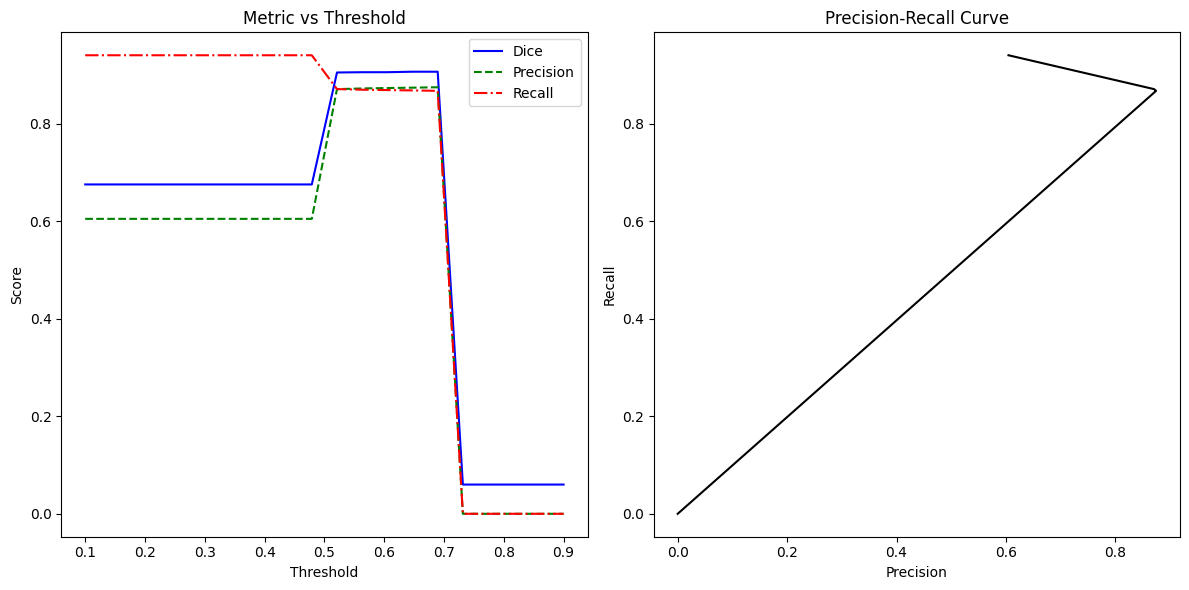

Optimal threshold: 0.647
Max Dice: 0.906
Precision at optimal: 0.874
Recall at optimal: 0.868


In [24]:
thresh = plot_threshold_analysis(threshold_df)

In [25]:
log_file = "/kaggle/working/model_logs.txt"
with open(log_file, "a") as f:
        f.write(f"Optimal Threshold: {thresh}\n")

In [26]:
!zip -r working.zip /kaggle/working/*

  adding: kaggle/working/checkpoint_epoch_10.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_11.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_12.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_13.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_14.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_15.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_16.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_17.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_18.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_19.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_1.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_20.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_21.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_22.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_23.pth (deflated 8%)
  adding: kaggle/working/checkpoint_epoch_24.pth (deflat